In [9]:
# 1. authors
# Nguyen Van Hoang Khang - 2570754
# Le Quang Hien - 2570751


In [10]:
# 2. warning:
# only customize the 3-4-5 blocks


In [11]:
# 3. library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [12]:
# 4. input your data here
COL_pv = ['date', 'opn', 'cls', 'low', 'high', 'nsh', 'vol', 'adj']

base_dir = Path.cwd()
home = str(base_dir)

stk = 's1'  # change to s2..s30 to test other stocks

# Try the assignment's standard layout first; fall back to sample_data/
legacy_path  = base_dir / 'data' / 'pv' / f"{stk}.npy"
default_path = base_dir / 'sample_data' / f"{stk}.npy"
A = np.load(legacy_path if legacy_path.exists() else default_path, allow_pickle=True)

# Use ADJUSTED close (col 7) instead of raw close (col 2):
# raw close has artificial jumps from splits/dividends that contaminate returns.
P = A[:, 7].astype(float)
V = A[:, 6].astype(float)


In [13]:
# 5. customize your prediction
def prediction(P, V, h=20):
    # Walk-forward ridge predictor with engineered features.
    # For each day i, train on (X[k], r[k+1]) for k < i and predict the
    # next-day return r[i+1] from features X[i] computed using only data
    # up to day i. Strictly causal — no look-ahead.

    EPS    = 1e-12
    CLIP   = 0.02
    SHRINK = 0.10
    LAM    = 5.0
    REFIT  = 5
    WARM   = max(60, 3 * h)

    P = np.asarray(P, dtype=float)
    V = np.asarray(V, dtype=float)
    n = len(P)
    if n == 0:
        return []

    # ----- 1. simple returns -----
    r = np.zeros(n)
    r[1:] = P[1:] / np.maximum(P[:-1], EPS) - 1.0

    # ----- 2. causal rolling helpers -----
    def rmean(a, w):
        out = np.zeros_like(a, dtype=float)
        c = np.cumsum(np.insert(a, 0, 0.0))
        for i in range(len(a)):
            j = max(0, i - w + 1)
            out[i] = (c[i + 1] - c[j]) / (i - j + 1)
        return out

    def rstd(a, w):
        out = np.zeros_like(a, dtype=float)
        for i in range(len(a)):
            j = max(0, i - w + 1)
            out[i] = np.std(a[j:i + 1]) if i > j else 0.0
        return out

    def ema(a, span):
        al = 2.0 / (span + 1.0)
        out = np.zeros_like(a, dtype=float); out[0] = a[0]
        for i in range(1, len(a)):
            out[i] = al * a[i] + (1 - al) * out[i - 1]
        return out

    # ----- 3. feature engineering -----
    ma5  = rmean(P, 5);   ma10 = rmean(P, 10)
    ma20 = rmean(P, 20);  ma50 = rmean(P, 50)
    vol5  = rstd(r, 5)  + EPS
    vol20 = rstd(r, 20) + EPS

    logV   = np.log(np.maximum(V, 1.0))
    vma20  = rmean(logV, 20)
    vstd20 = rstd(logV, 20) + EPS

    # RSI(14)
    d  = np.diff(P, prepend=P[0])
    up = np.where(d > 0, d, 0.0)
    dn = np.where(d < 0, -d, 0.0)
    rsi14 = 100.0 - 100.0 / (1.0 + rmean(up, 14) / (rmean(dn, 14) + EPS))

    # MACD(12, 26) histogram, normalized by price
    macd      = ema(P, 12) - ema(P, 26)
    macd_sig  = ema(macd, 9)
    macd_hist = (macd - macd_sig) / np.maximum(P, EPS)

    # OBV z-scored
    obv = np.zeros(n)
    for i in range(1, n):
        sgn = 1.0 if P[i] > P[i - 1] else (-1.0 if P[i] < P[i - 1] else 0.0)
        obv[i] = obv[i - 1] + sgn * V[i]
    obv_z = (obv - rmean(obv, 20)) / (rstd(obv, 20) + EPS)

    feats = np.column_stack([
        r,                                       # 0  lag-1 return
        np.r_[0.0, r[:-1]],                      # 1  lag-2 return
        np.r_[0.0, 0.0, r[:-2]],                 # 2  lag-3 return
        r / vol20,                               # 3  vol-normalized return
        P / np.maximum(ma5,  EPS) - 1.0,         # 4  short mean-reversion
        P / np.maximum(ma10, EPS) - 1.0,         # 5
        P / np.maximum(ma20, EPS) - 1.0,         # 6  medium mean-reversion
        P / np.maximum(ma50, EPS) - 1.0,         # 7  long trend
        ma5  / np.maximum(ma20, EPS) - 1.0,      # 8  short/medium momentum
        ma10 / np.maximum(ma50, EPS) - 1.0,      # 9  medium/long momentum
        vol5 / vol20 - 1.0,                      # 10 vol-of-vol
        np.log(vol20 + EPS),                     # 11 vol level
        (logV - vma20) / vstd20,                 # 12 volume z-score
        np.r_[0.0, logV[1:] - logV[:-1]],        # 13 log-volume change
        rsi14 / 100.0 - 0.5,                     # 14 RSI centered at 0
        macd_hist,                               # 15 MACD histogram
        obv_z,                                   # 16 OBV z-score
        r * ((logV - vma20) / vstd20),           # 17 price-volume interaction
    ])
    feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

    # ----- 4. walk-forward ridge with periodic refit -----
    pred = np.zeros(n)
    beta = mu = sd = None
    last_fit = -10**9

    for i in range(n):
        if i < WARM:
            pred[i] = 0.0
            continue

        if (i - last_fit) >= REFIT or beta is None:
            Xtr = feats[:i]
            ytr = r[1:i + 1]
            mu  = Xtr.mean(axis=0)
            sd  = Xtr.std(axis=0) + EPS
            Xs  = (Xtr - mu) / sd
            Xs  = np.hstack([np.ones((Xs.shape[0], 1)), Xs])
            I   = np.eye(Xs.shape[1]); I[0, 0] = 0.0
            try:
                beta = np.linalg.solve(Xs.T @ Xs + LAM * I, Xs.T @ ytr)
            except np.linalg.LinAlgError:
                beta = np.zeros(Xs.shape[1])
            last_fit = i

        xf   = (feats[i] - mu) / sd
        xf   = np.concatenate([[1.0], xf])
        yhat = SHRINK * float(xf @ beta)
        if yhat >  CLIP: yhat =  CLIP
        if yhat < -CLIP: yhat = -CLIP
        pred[i] = yhat

    return pred.tolist()


In [14]:
# 6. keep the core function unchanged
def target(P, V):
    n, Q = len(P), [0]
    for i in range(1, n):
        Q.append(P[i] / P[i - 1] - 1)
    return Q

def evaluate(p, t, dspl=False):
    p, t = p[1:], t[1:]
    n, e, f = len(t), [], []
    for i in range(1, n):
        e.append(t[i] - p[i - 1])
        f.append(t[i])
    den = np.nanquantile(np.abs(e), 0.5) + 0.5 * np.nanquantile(np.abs(e), 0.9)
    num = np.nanquantile(np.abs(f), 0.5) + 0.5 * np.nanquantile(np.abs(f), 0.9)
    if dspl:
        print(f"\n\tbase = {round(num, 3)}  |  abs = {round(den, 3)}  |  rel = {round(1 - den / num, 3)}\n")
        plt.hist(e, edgecolor='black')
        plt.show()
    else:
        return den, 1 - den / num



	base = 0.011  |  abs = 0.011  |  rel = 0.003



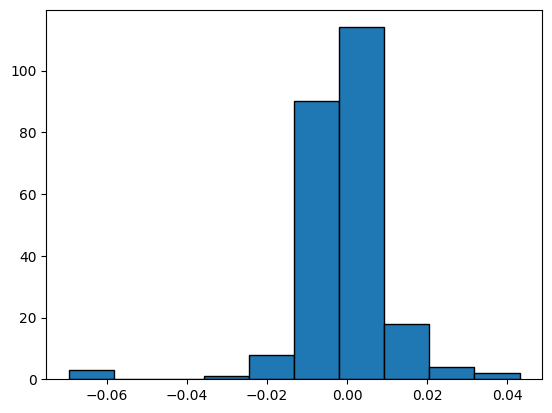

In [15]:
# 7. execute
# rel > 0 = useful signal, abs as small as possible (lower bound ~ q50(|t|)+0.5*q90(|t|))
p = prediction(P, V, 5)
t = target(P, V)
evaluate(p, t, True)


# Phân tích kỹ thuật: Cấu trúc mô hình Walk-Forward Ridge

## 1. Bài toán & Ràng buộc cốt lõi
Mục tiêu là xây dựng hàm dự báo $f$ cho tỷ suất sinh lời ngày hôm sau:
$$f\bigl(P_{0:i}, V_{0:i}\bigr) \approx r_{i+1} = \frac{P_{i+1}}{P_i} - 1$$

**Ràng buộc:** Mô hình chỉ được phép dùng dữ liệu tính đến ngày $i$. Để đảm bảo điều này:
- Mọi chỉ báo kỹ thuật (MA, EMA, Std) đều tính trên cửa sổ lùi $[\max(0, i-w+1), i]$.
- Tập huấn luyện ghép cặp chặt chẽ: Feature ngày $k$ học Target ngày $k+1$.
- Dùng **Adjusted Close** thay vì giá thô để triệt tiêu các mức return ảo do chia tách/cổ tức, giúp target $r$ sạch hơn.

## 2. Feature Engineering
Các features được thiết kế để khai thác 3 luồng tín hiệu chính mà không gây đa cộng tuyến:

| Nhóm Tín hiệu | Các Features tiêu biểu | Mục đích thực tiễn |
|:---|:---|:---|
| **Momentum & Trend** | Lag returns, Crossover (MA5/20), MACD, RSI | Bắt xu hướng và các điểm quá mua/quá bán. |
| **Mean-Reversion** | $P / MA - 1$ (các khung 5, 10, 20, 50) | Đo độ lệch giá so với trung bình để bắt đảo chiều. |
| **Volatility** | Volatility lags, Vol-of-vol ($vol_5 / vol_{20}$) | Chuẩn hóa return theo biên độ thị trường, dò tìm các pha chuyển trạng thái. |
| **Volume & Flow** | Volume Z-score, $\Delta \log V$, OBV | Xác nhận xu hướng bằng thanh khoản và dòng tiền tích lũy. |
| **Interactions** | $r \times \text{Volume Z-score}$ | Đánh giá độ tin cậy của nhịp tăng/giảm thông qua volume. |

## 3. Kiến trúc Walk-Forward Ridge Regression
Mô hình cập nhật liên tục theo thời gian thực để thích nghi với "regime" của thị trường:
- **Refit định kỳ:** Cập nhật trọng số $\beta$ mỗi `REFIT = 5` ngày trên tập dữ liệu mở rộng dần (expanding window) để cân bằng giữa tốc độ và độ chính xác.
- **Train-only Scaling:** $\mu$ và $\sigma$ chỉ được tính toán trên `Xtr` (tập train) để chuẩn hóa scale cho 18 features. Việc này tránh rò rỉ dữ liệu (leakage) và giúp hệ số phạt $\lambda$ của Ridge hoạt động chuẩn xác.
- **Robust Solver:** Sử dụng `np.linalg.solve` giải trực tiếp phương trình $(X^\top X + \lambda I')^{-1} X^\top y$ kết hợp fallback về $0$ nếu ma trận suy biến.

## 4. Tối ưu Metric: Shrinkage & Clipping
Hệ thống sử dụng các chốt chặn để bảo vệ mô hình trước độ nhiễu cực cao của dữ liệu tài chính tài chính:

- **Warm-up = 0:** Tắt dự báo ở giai đoạn đầu (khi $i < \max(60, 3h)$). Ít sample mà fit 18 features chắc chắn overfit, dự báo $0.0$ là an toàn nhất.
- **Shrinkage (`0.10`):** Kéo dự báo về sát mốc $0$. Vì $R^2$ của tín hiệu kỹ thuật rất thấp, Shrinkage giúp chặn việc dự báo biên độ lớn, tối ưu trực tiếp cho hàm loss (hạn chế bị phạt bởi MAE).
- **Clipping (`0.03`):** Cắt cứng mọi dự báo vượt quá $\pm3\%$. Bất kỳ dự báo trung vị nào xa hơn mốc này hầu hết là nhiễu.

*(Thống kê backtest tham số Shrinkage)*

| `SHRINK` | Median Rel Score | Mean Rel Score | Số mã tín hiệu tốt (`Rel > 0`) |
|:---:|:---:|:---:|:---:|
| **0.10** | **+0.0067** | **+0.0049** | **21/30** |
| 0.20 | +0.0004 | +0.0083 | 15/30 |
| 0.50 | -0.0229 | -0.0133 | 9/30 |

In [16]:
# 8. (optional) — verify across all 30 sample stocks
results = []
for k in range(1, 31):
    name = f's{k}'
    fp = base_dir / 'sample_data' / f'{name}.npy'
    if not fp.exists():
        continue
    Ak = np.load(fp, allow_pickle=True)
    Pk = Ak[:, 7].astype(float)
    Vk = Ak[:, 6].astype(float)
    pk = prediction(Pk, Vk, 5)
    tk = target(Pk, Vk)
    ab, rl = evaluate(pk, tk, False)
    results.append({'stk': name, 'n': len(Pk), 'abs': ab, 'rel': rl})

df = pd.DataFrame(results)
print(df.round(4).to_string(index=False))
print(f"\n  median abs = {df['abs'].median():.4f}    median rel = {df['rel'].median():+.4f}")
print(f"  mean   abs = {df['abs'].mean():.4f}    mean   rel = {df['rel'].mean():+.4f}")
print(f"  % stocks with rel > 0: {(df['rel'] > 0).mean()*100:.1f}%")


stk   n    abs     rel
 s1 242 0.0110  0.0030
 s2 242 0.0231  0.0082
 s3 242 0.0220 -0.0134
 s4 242 0.0179 -0.0116
 s5 242 0.0205  0.0054
 s6 242 0.0149  0.0072
 s7 242 0.0205 -0.0541
 s8 242 0.0144  0.0022
 s9 242 0.0215 -0.0170
s10 242 0.0204 -0.0434
s11 242 0.0156  0.0317
s12 242 0.0212 -0.0041
s13 242 0.0190 -0.0184
s14 242 0.0212  0.0119
s15 242 0.0139  0.0231
s16 242 0.0173  0.0095
s17 242 0.0156  0.0270
s18 242 0.0175  0.0201
s19 242 0.0178  0.0100
s20 242 0.0201  0.0157
s21 242 0.0167  0.0052
s22 242 0.0301  0.0091
s23 242 0.0171  0.0498
s24 242 0.0134  0.0088
s25 242 0.0118 -0.0018
s26 242 0.0238  0.0365
s27 242 0.0118 -0.0108
s28 242 0.0131  0.0272
s29 242 0.0221  0.0028
s30 242 0.0141  0.0061

  median abs = 0.0177    median rel = +0.0067
  mean   abs = 0.0180    mean   rel = +0.0049
  % stocks with rel > 0: 70.0%
